Brianna Lannerd, 08/31/2026
Lab 2 — Energy-Tracking Projectile. This lab incorporates the calculation and plotting of energy in a projectile motion system. It compares the 
two methods of Standard Euler and Euler Cromer.
Disclaimer: Code was modeled after code given in code module 2 lesson. AI was used to trouble shoot and fix the code when it errored. 

In [60]:
# Import Libraries
import numpy as np
import matplotlib.pyplot as plt

Part A- Add Energy Tracking

In [61]:
#Part A Section 1: Projectile Motion with Energy Tracking. I had to modify the code from the previous lab because I did the lab incorrectly, so I tried to
#combine my function with the functions from the code section of module two lectures.

def simulate_projectile_energy(v0, theta_deg, dt, g=9.81, m=1.0):
    x, y = 0.0, 0.0
    vx = v0*np.cos(np.radians(theta_deg))
    vy = v0*np.sin(np.radians(theta_deg))
    t = 0.0

    data = {'t': [0], 'x': [x], 'y': [y], 'vx': [vx], 'vy': [vy],
            'KE': [0.5*m*(vx**2+vy**2)], 'PE': [m*g*y], 'E': [0.5*m*(vx**2+vy**2)+m*g*y]}

    while y >= 0:
        ax, ay = 0.0, -g

        # Standard Euler
        vx_old, vy_old = vx, vy
        vx = vx + ax*dt
        vy = vy + ay*dt
        x = x + vx_old*dt
        y = y + vy_old*dt

        t += dt

        # Energy tracking
        KE = 0.5 * m * (vx**2 + vy**2)
        PE = m * g * y
        E = KE + PE

        data['t'].append(t)
        data['x'].append(x); data['y'].append(y)
        data['vx'].append(vx); data['vy'].append(vy)
        data['KE'].append(KE); data['PE'].append(PE); data['E'].append(E)

    return data

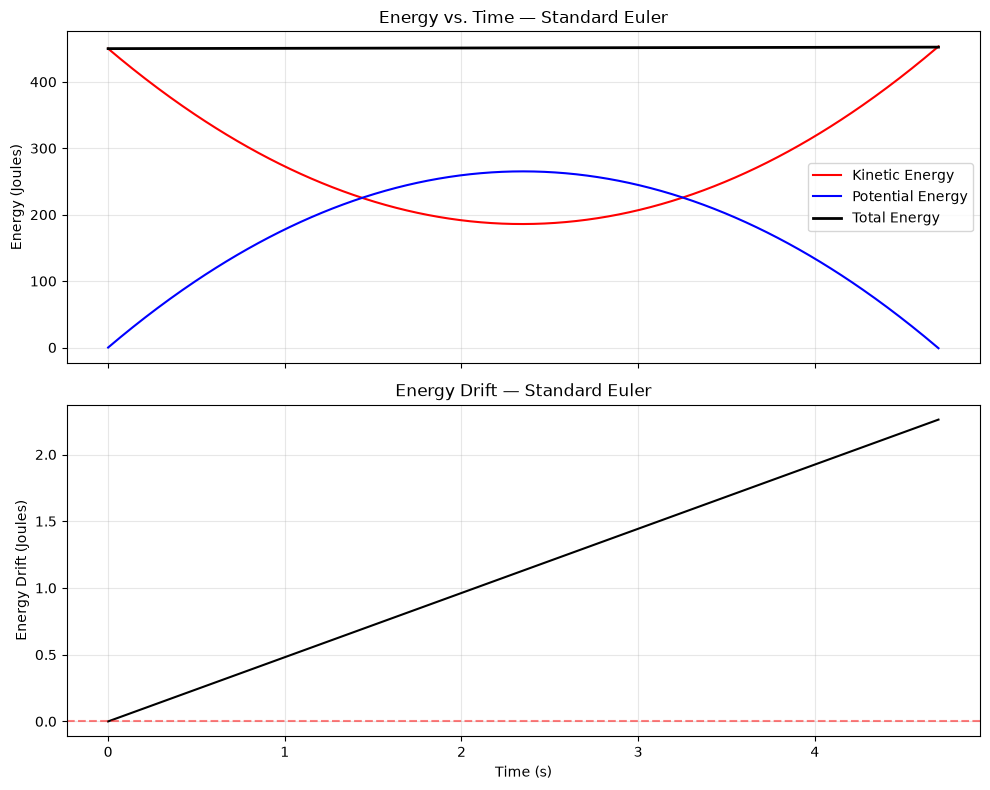

In [62]:
#Part A Section 2: Initial Launch Parameters. Speed 30m/s at 50 degrees above the horizontal, with a timestep of 0.01 seconds. 
data = simulate_projectile_energy(30, 50, 0.01) 

#Part A Section 3: Plotting the results
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 8), sharex=True)

# Upper plot: Kinetic Energy (red), Potential Energy (blue), Total Energy (black)
ax1.plot(data['t'], data['KE'], 'r-', label='Kinetic Energy')
ax1.plot(data['t'], data['PE'], 'b-', label='Potential Energy')
ax1.plot(data['t'], data['E'], 'k-', label='Total Energy', linewidth=2)
ax1.set_ylabel('Energy (Joules)')
ax1.legend()
ax1.set_title('Energy vs. Time — Standard Euler')
ax1.grid(True, alpha=0.3)

# Lower plot: energy drift
E0 = data['E'][0]
E_drift = np.array(data['E']) - E0
ax2.plot(data['t'], E_drift, 'k-')
ax2.set_xlabel('Time (s)')
ax2.set_ylabel('Energy Drift (Joules)')
ax2.set_title('Energy Drift — Standard Euler')
ax2.grid(True, alpha=0.3)
ax2.axhline(y=0, color='r', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

The graph on top shows the energy conservation of the projectile by showing at any time, the potential and kinetic energy as well as the total energy. If energy is conserved (with this current "ideal" environment), at any point on the graph, the potential energy added to the kinetic energy should equal the total energy. The total energy should also be a straight horizontal line (constant) for the entire time. Because the scale for the y-axis goes by 100 joules, it would be difficult to visually tell if the total amount of energy actually stays constant even though it appears to. The graph on the bottom shows the energy drift. As expected with the standard Euler model, the total energy drift curve is a straight, positively sloped diagnol. This means the energy total is slowly growing at a constant rate over the flight of the projectile. 

In [63]:
#Part A Section 4: Energy Drift Analysis. I calculated the maximum absolute energy drift and the maximum energy drift as a percentage of the initial energy.
max_drift = np.max(np.abs(E_drift))
percent_drift = max_drift/abs(E0)*100

print(f"Maximum absolute energy drift = {max_drift:.5f} J")
print(f"Maximum energy drift (percent of the initial energy) = {percent_drift:.5f}%")

Maximum absolute energy drift = 2.26155 J
Maximum energy drift (percent of the initial energy) = 0.50257%


Part B- Euler vs Euler-Cromer Methods

In [64]:
#Part B Section 1:
#The function below is controlled by the method argument. It allows for the two methods (Euler and Euler-Cromer) to be used for the projectile motion simulation. It returns arrays of time, position, velocity, and energy values.
def simulate_projectile(method, dt, v0=30, theta_deg=50, g=9.81, m=1.0):
    x, y = 0.0, 0.0
    vx = v0*np.cos(np.radians(theta_deg))
    vy = v0*np.sin(np.radians(theta_deg))
    t = 0.0

    ts, xs, ys, vxs, vys = [t], [x], [y], [vx], [vy]

    KE = 0.5*m*(vx**2 + vy**2)
    PE = m*g*y
    E = KE + PE
    KEs, PEs, Es = [KE], [PE], [E]

    while y >= 0:
        ax, ay = 0.0, -g

        if method == 'euler':
            vx_old, vy_old = vx, vy
            vx = vx + ax*dt 
            vy = vy + ay*dt
            x = x + vx_old*dt #uses old velocity for position update
            y = y + vy_old*dt

        elif method == 'euler-cromer':
            vx = vx + ax*dt
            vy = vy + ay*dt
            x = x + vx*dt #uses new velocity for position update
            y = y + vy*dt

        t += dt
        #Calculate energies
        KE = 0.5*m*(vx**2 + vy**2) 
        PE = m*g*y
        E = KE + PE

        ts.append(t); xs.append(x); ys.append(y)
        vxs.append(vx); vys.append(vy)
        KEs.append(KE); PEs.append(PE); Es.append(E)

    return np.array(ts), np.array(xs), np.array(ys), np.array(vxs), np.array(vys), np.array(KEs), np.array(PEs), np.array(Es)

In [65]:
#Part B. Section 2. Initial Launch Conditions are defined in the function. Initial speed of 30 m/s at an angle of 50 degrees above the horizontal, with a timestep of 0.01 seconds.
t_e, x_e, y_e, vx_e, vy_e, KE_e, PE_e, E_e = simulate_projectile('euler', 0.01)
t_ec, x_ec, y_ec, vx_ec, vy_ec, KE_ec, PE_ec, E_ec = simulate_projectile('euler-cromer', 0.01)

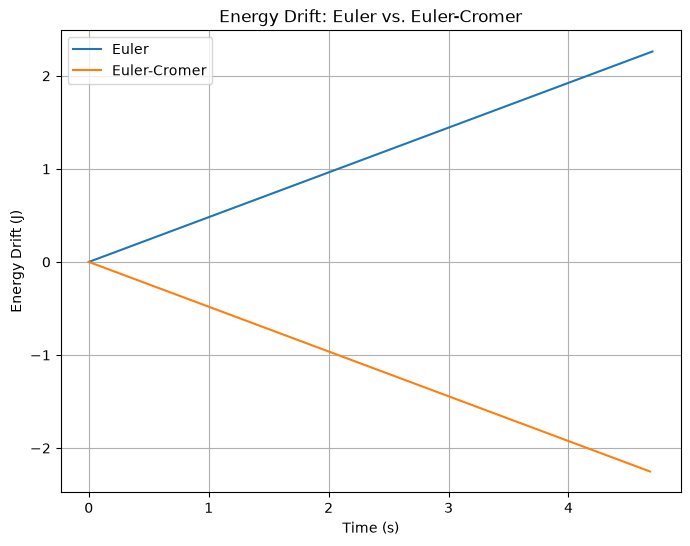

In [ ]:
#Part B. Section 3: Overlay the Energy drift.

drift_e = E_e - E_e[0]
drift_ec = E_ec - E_ec[0]

plt.figure(figsize=(8,6))
plt.plot(t_e, drift_e, label='Euler')
plt.plot(t_ec, drift_ec, label='Euler-Cromer')
plt.xlabel('Time (s)')
plt.ylabel('Energy Drift (J)')
plt.title('Energy Drift: Euler vs. Euler-Cromer')
plt.legend()
plt.grid(True)
plt.show()

The result of the graph above would have surprised me if I hadn't read the code lesson module. As shown above, for a projectile in uniform gravity,
the Euler method is not less accurate than the Euler-Cromer method. As shown by the symettry the two graphs have around the X axis, their energy drifts (or their errors) have the same magnitude and are opposites of eachother. (Negative vs positive slope). The projectile can not distinquish the two methods because the force doesn't depend on position, so the velocity is the exact in both methods. 

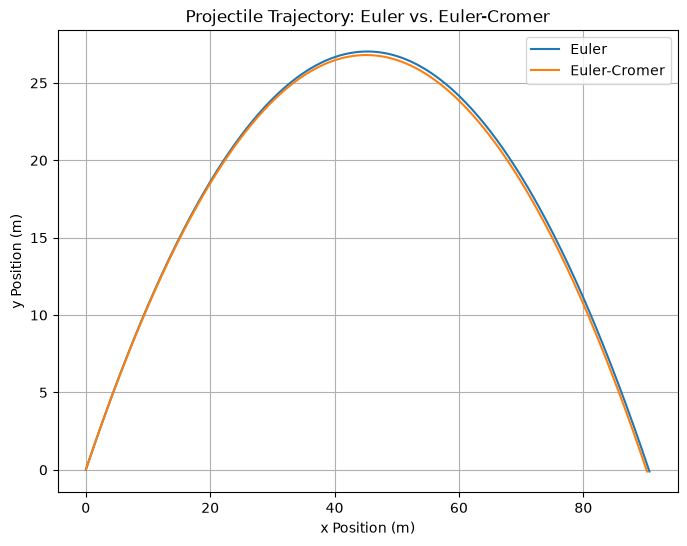

In [67]:
# Part B. Section 4: Overlay and compare the trajectories of the two methods.
plt.figure(figsize=(8,6))
plt.plot(x_e, y_e, label='Euler')
plt.plot(x_ec, y_ec, label='Euler-Cromer')
plt.xlabel('x Position (m)')
plt.ylabel('y Position (m)')
plt.title('Projectile Trajectory: Euler vs. Euler-Cromer')
plt.legend()
plt.grid(True)
plt.show()

As shown above, the two methods can be visibly distinguished when viewing their overlayed trajectories. It appears that the range of the projectile when using the Euler- Cromer method is slighly shorter than when using the Euler method. 

In [68]:
range_e = x_e[-1]
range_ec = x_ec[-1]

difference = abs(range_e - range_ec)

print("Euler range =", range_e)
print("Euler-Cromer range =", range_ec)
print("Difference =", difference)

Euler range = 90.63305296580204
Euler-Cromer range = 90.24738039999012
Difference = 0.385672565811916


As seen visually in the graph and calculated above, there is a difference in the landing range between the two methods. Both methods use the same intial parameters and timestep, so there must be a physical reason they have different landing ranges. For the standard Euler equation, the old velocity is used to update the position. This means its approximate overestimates the position, which adds energy to the system as shown by the positive energy drift graph created earlier. Euler-Cromer updates velocity first and then uses the new velocity to update the position. This helps reduce the amount of the overestimate of the approximation which in the case of uniform gravity, results in the same energy that Standard Euler added to the system to be removed from the system as shown by the negatively sloped energy drift graph.

Part C- Convergence Study

In [69]:
#Part C. Section 1: Running gravity-only projectile for a range of step sizes.
dts = np.array([0.1, 0.05, 0.025, 0.0125, 0.00625])

drifts_e = []
drifts_ec = []

#Part C. Section 2: Recording the maximum energy drift for each method and each timestep.
for dt in dts:
    t, x, y, vx, vy, KE, PE, E = simulate_projectile('euler', dt)
    drift = E - E[0]
    drifts_e.append(np.max(np.abs(drift)))

    t, x, y, vx, vy, KE, PE, E = simulate_projectile('euler-cromer', dt) #Part C. Section 4. Building in the "repeat" of the simulation for the Euler-Cromer method to record the maximum energy drift for each timestep.
    drift = E - E[0]
    drifts_ec.append(np.max(np.abs(drift)))

drifts_e = np.array(drifts_e)
drifts_ec = np.array(drifts_ec)

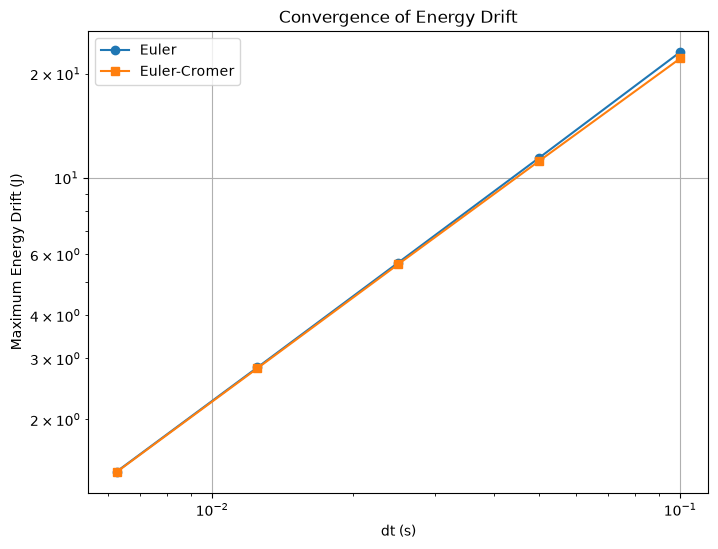

In [70]:
#Part C. Section 3: Log-log plot of mazimum energy drift vs. timestep for both methods.
plt.figure(figsize=(8,6))
plt.loglog(dts, drifts_e, 'o-', label='Euler')
plt.loglog(dts, drifts_ec, 's-', label='Euler-Cromer')
plt.xlabel('dt (s)')
plt.ylabel('Maximum Energy Drift (J)')
plt.title('Convergence of Energy Drift')
plt.legend()
plt.grid(True)
plt.show()

In [71]:
#Part C. Section 5: Report the slopes of both curves and interpret them.
slope_e = np.polyfit(np.log(dts), np.log(drifts_e), 1)[0]
slope_ec = np.polyfit(np.log(dts), np.log(drifts_ec), 1)[0]

print(f"Euler slope = {slope_e:.2f}")
print(f"Euler-Cromer slope = {slope_ec:.2f}")

Euler slope = 1.01
Euler-Cromer slope = 0.99


Both the slopes for standard euler and euler cromer were approximately one. Both methods were also the same "distance" from a slope of one. +- 0.01 within 1. As explained in the lesson module, the slope of approximately one indicates a first order method of convergence. This means that for these methods, when dt is halved, it halves the error. The slopes both being positive also defends this idea because it shows as dt increases, the maximum energy drift increases at a constant rate. 

1. The measured order of p of standard Euler for energy drift is approximately 1. This matches the prediction in the week 2 lesson for a first order method. As explained, if you cut the dt in half for a first order method, the error will also be halved (which means the maximum energy drift si also approximately cut in half). 
2. The Euler-Cromer's convergence is very simular to the standard Euler's convergence curve. Visually, both methods appear to have the same energy drift for very very small step sizes. As the step sizes increased, however, Euler-Cromer's energy drift because slightly smaller at a constant rate compared to the standard Euler. This can be easily seen in the calculation of the slope as well since the Euler-Cromer slope is 0.02 less than the standard Euler, it makes since that for every increase in dt, euler cromer's energy drift increases less than the standard eulers. 
3. If energy needed to be conserved within 0.01%, I would use a step size of 0.0002. This comes from the idea that if you halve the timestep you also halve the error. In Part A, I calculated an error of approximately 0.5% when the timestep was 0.01. Since the slope is approximately 1, the error is proportional to dt. To find how many times you have to halve it to get to 0.01% you have to divide 0.5/0.01 which results in a factor of 50. Then you divide the timestep of 0.01/50 to get 0.0002. 

Bonus- Drag and Physical Energy Loss

In [ ]:
# Bonus Section 1
def simulate_drag_energy(v0, theta_deg, dt, g=9.81, m=1.0, b_over_m=0.0046):
    x, y = 0.0, 0.0
    vx = v0*np.cos(np.radians(theta_deg))
    vy = v0*np.sin(np.radians(theta_deg))
    t = 0.0

    KE = 0.5*m*(vx**2 + vy**2)
    PE = m*g*y
    E = KE + PE

    ts, xs, ys = [t], [x], [y]
    vxs, vys, Es = [vx], [vy], [E]
    W_drag = 0.0

    while y >= 0:
        speed = np.sqrt(vx**2 + vy**2)

        # Drag 
        Fdx = -m*b_over_m*speed*vx
        Fdy = -m*b_over_m*speed*vy

        # Work done by drag 
        W_drag += (Fdx*vx + Fdy*vy)*dt

       
        ax = Fdx/m
        ay = -g + Fdy/m

        # Euler-Cromer
        vx = vx + ax*dt
        vy = vy + ay*dt
        x = x + vx*dt
        y = y + vy*dt

        t += dt

        KE = 0.5*m*(vx**2 + vy**2)
        PE = m*g*y
        E = KE + PE

        ts.append(t); xs.append(x); ys.append(y)
        vxs.append(vx); vys.append(vy); Es.append(E)

    return np.array(ts), np.array(xs), np.array(ys), np.array(vxs), np.array(vys), np.array(Es), W_drag

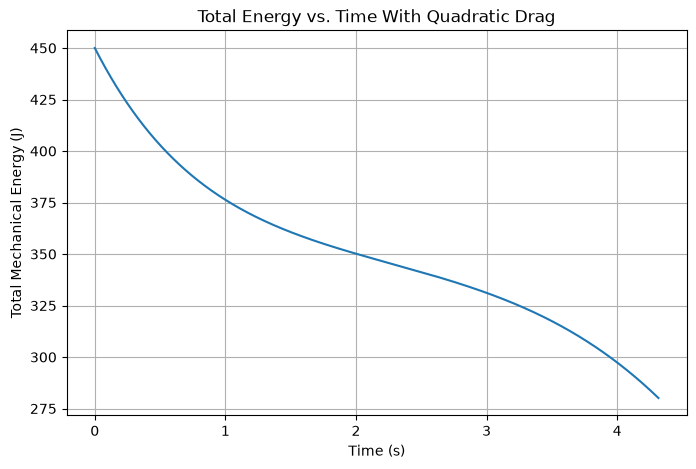

In [73]:
t_d, x_d, y_d, vx_d, vy_d, E_d, W_drag = simulate_drag_energy(30, 50, 0.001)
plt.figure(figsize=(8,5))
plt.plot(t_d, E_d)
plt.xlabel('Time (s)')
plt.ylabel('Total Mechanical Energy (J)')
plt.title('Total Energy vs. Time With Quadratic Drag')
plt.grid(True)
plt.show()

This shows the total mechanical energy decreases continuously throughout the projectile's flight. The rate of decrease is not constant as shown by the slope changing at different rates on different times. This shows how the drag force is non-conservative as taught in previous physics classes. The mechanical energy can be converted to other energy forms like heat that is not measured in this simulation.

In [74]:
#Parts 2/3:
E_lost = E_d[0] - E_d[-1]
work_against_drag = -W_drag
difference = abs(E_lost - work_against_drag)
percent_difference = difference/E_lost*100

print("Mechanical energy lost =", E_lost, "J")
print("Work done against drag =", work_against_drag, "J")
print("Difference =", difference, "J")
print("Percent difference =", percent_difference, "%")

Mechanical energy lost = 169.87084685393222 J
Work done against drag = 169.67175095397792 J
Difference = 0.1990958999543011 J
Percent difference = 0.11720427821584876 %


This shows the difference in mechanical energy lost and work done against drag is very small as it is less than 1 percent.